# Non-functional Quality of LLM-Generated Patches — Results Notebook

Loads the five CSVs in `csv/`, produced by `extract_results.py`, and reproduces the figures/tables for the paper's Results section.

**Outline (mirrors paper)**
- §IV.A  Functional outcomes — already in main.tex Table I (no compute here)
- §IV.B  CodeQL findings — overall (RQ1)
- §IV.C  CodeQL by category — security / maintainability / reliability (RQ2)
- §IV.D  CodeScene code health changes (RQ1)
- §IV.E  CodeScene category patterns (RQ2)
- §IV.F  Cross-tool synthesis (RQ1+RQ2)

**Sample.** Main analysis filters each model to its `resolved_ids ∩ available diff files`. Gold patches included only in §IV.D/E (CodeScene only). For CodeScene, an empty `{}` diff means "patch did not touch code health" — counted as a zero, not dropped, unless explicitly noted.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
CSV = ROOT / 'csv'
FIG = ROOT / 'figures'
FIG.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', context='paper', font_scale=1.35)
plt.rcParams.update({'axes.titlesize': 12, 'axes.labelsize': 12,
                     'xtick.labelsize': 12, 'ytick.labelsize': 12,
                     'legend.fontsize': 12})
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

# Model display order (newer first within family, used throughout)
MODEL_ORDER = ['Claude Opus 4.6', 'Claude Sonnet 4', 'DeepSeek V3.2', 'DeepSeek R1']
MODEL_ORDER_WITH_GOLD = MODEL_ORDER + ['Gold (developer)']
GEN_COLORS = {'newer': '#2b8cbe', 'older': '#fdae61', 'gold': '#7f7f7f'}

def palette(models):
    gen_map = dict(zip(
        ['Claude Opus 4.6','Claude Sonnet 4','DeepSeek V3.2','DeepSeek R1','Gold (developer)'],
        ['newer','older','newer','older','gold']
    ))
    return [GEN_COLORS[gen_map[m]] for m in models]

summary    = pd.read_csv(CSV / 'model_summary.csv')
ql_inst    = pd.read_csv(CSV / 'codeql_per_instance.csv')
ql_rule    = pd.read_csv(CSV / 'codeql_rule_counts.csv')
cs_inst    = pd.read_csv(CSV / 'codescene_per_instance.csv')
cs_find    = pd.read_csv(CSV / 'codescene_finding_counts.csv')
catalog    = pd.read_csv(CSV / 'rule_catalog.csv')

# Filter to resolved-only views
ql_R = ql_inst[ql_inst['is_resolved'] == 1].copy()
patch_size = pd.read_csv(CSV / 'patch_metrics.csv')
cs_R = cs_inst[cs_inst['is_resolved'] == 1].copy()
summary

,model,generation,family,submitted,completed,resolved,n_codeql_available,n_codescene_available,n_codescene_nonempty,n_codeql_resolved_intersect,n_codescene_resolved_intersect,n_codescene_resolved_nonempty
0,Claude Opus 4.6,newer,Claude,300,178,133,133,133,51,133,133,51
1,Claude Sonnet 4,older,Claude,300,174,108,108,108,60,108,108,60
2,DeepSeek V3.2,newer,DeepSeek,300,214,133,133,133,60,133,133,60
3,DeepSeek R1,older,DeepSeek,231,212,79,79,79,37,79,79,37
4,Gold (developer),gold,Gold,300,300,300,194,194,91,194,194,91


## §IV.A  Overall direction share — both tools (RQ1 headline)


CodeQL direction share (%):
_dir              regress  neutral  improve
model                                      
Claude Opus 4.6       5.3     94.0      0.8
Claude Sonnet 4      14.8     84.3      0.9
DeepSeek V3.2         9.0     88.7      2.3
DeepSeek R1          11.4     87.3      1.3
Gold (developer)     50.5     49.0      0.5

CodeScene direction share (%):
_dir              regress  neutral  improve
model                                      
Claude Opus 4.6      15.8     83.5      0.8
Claude Sonnet 4      25.9     74.1      0.0
DeepSeek V3.2        26.3     72.2      1.5
DeepSeek R1          22.8     75.9      1.3
Gold (developer)     19.6     79.4      1.0


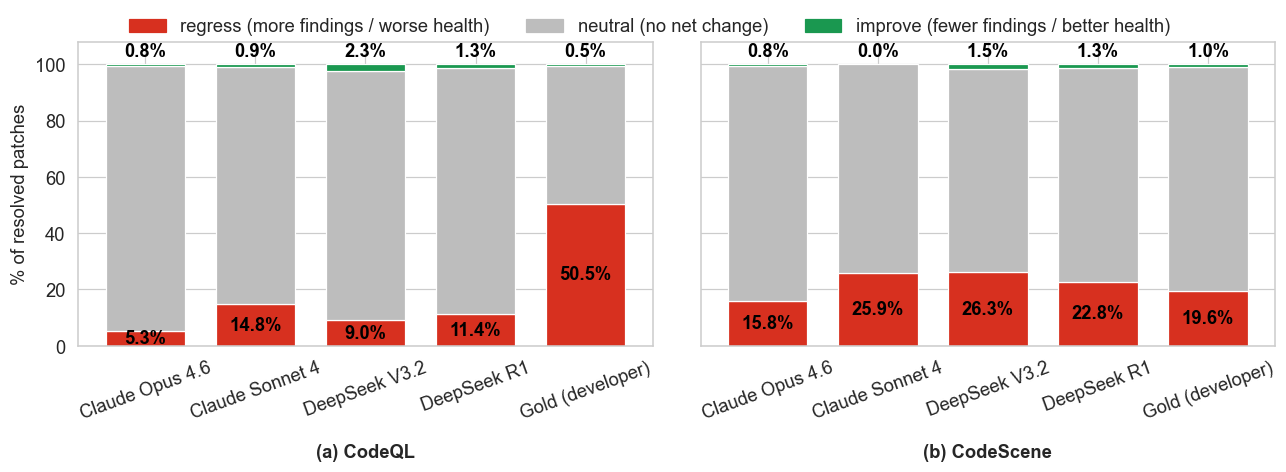

In [2]:
# Per-model regress / neutral / improve share on each model's own resolved set.
# CodeQL:    net = added − removed; > 0 → regress, < 0 → improve.
# CodeScene: sign of score_delta_min; empty diffs / NaN → neutral
#            (CodeScene score: higher = healthier, so delta < 0 means regression).
ORDER_ALL = MODEL_ORDER_WITH_GOLD

def _bucket_ql(n):
    return 'regress' if n>0 else ('improve' if n<0 else 'neutral')
def _bucket_cs(delta, empty):
    if empty or pd.isna(delta) or delta == 0:
        return 'neutral'
    return 'regress' if delta < 0 else 'improve'

ql_R['_dir'] = ql_R['net'].apply(_bucket_ql)
cs_R['_dir'] = cs_R.apply(lambda r: _bucket_cs(r['score_delta_min'], r['is_empty_diff']==1), axis=1)

def _share(df):
    pct = (df.groupby('model')['_dir'].value_counts(normalize=True).unstack(fill_value=0)*100)
    return pct.reindex(ORDER_ALL).fillna(0)[['regress','neutral','improve']]

ql_share = _share(ql_R)
cs_share = _share(cs_R)
print('CodeQL direction share (%):');    print(ql_share.round(1));   print()
print('CodeScene direction share (%):'); print(cs_share.round(1))

# Stacked bar, side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
COLORS = ['#d7301f', '#bdbdbd', '#1a9850']     # regress / neutral / improve

for ax, share, title in [(axes[0], ql_share, '(a) CodeQL'),
                         (axes[1], cs_share, '(b) CodeScene')]:
    share.plot(kind='bar', stacked=True, ax=ax, color=COLORS, width=0.72, legend=False)
    ax.set_ylim(0, 108)
    ax.set_xlabel('')
    ax.annotate(title, xy=(0.5, -0.32), xycoords='axes fraction',
                ha='center', va='top', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    # annotate regress + improve % on each bar (skip 0%)
    for i, m in enumerate(share.index):
        r, _, im = share.loc[m]
        if r > 0.5:
            ax.text(i, r/2, f'{r:.1f}%', ha='center', va='center',
                    fontsize=12, color='black', fontweight='bold')
        ax.text(i, 100 + 1.5, f'{im:.1f}%', ha='center', va='bottom',
                fontsize=12, color='black', fontweight='bold')

axes[0].set_ylabel('% of resolved patches')
handles = [plt.Rectangle((0,0),1,1, color=c) for c in COLORS]
fig.legend(handles, ['regress (more findings / worse health)',
                     'neutral (no net change)',
                     'improve (fewer findings / better health)'],
           loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.04), frameon=False, fontsize=12)
plt.tight_layout()
plt.savefig(FIG / 'fig_overall_direction_share.png')
plt.show()


## §IV.B  Newer-vs-older pooled comparison (RQ1)


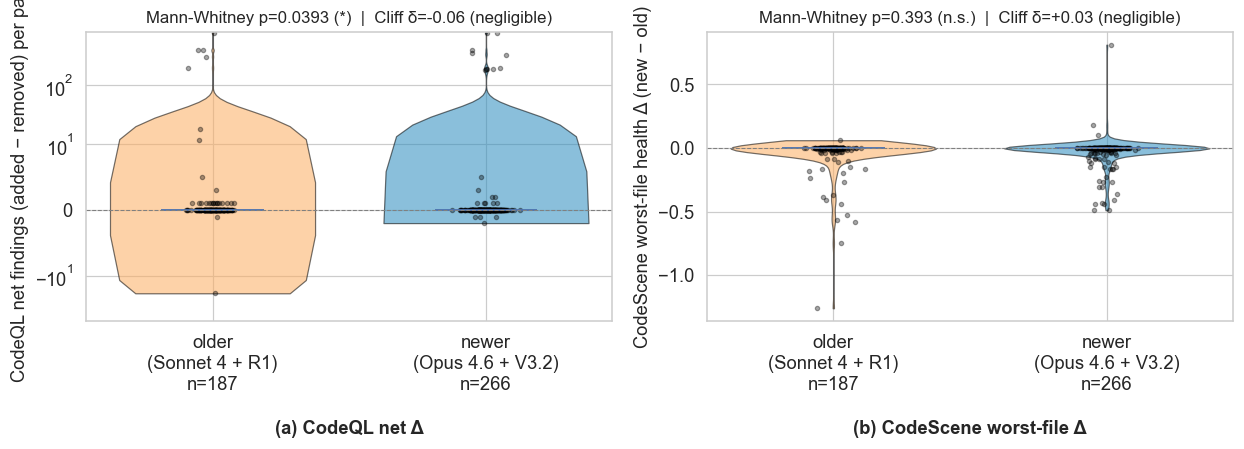

In [3]:
# Pool the four LLMs into newer = {Opus 4.6, V3.2} vs older = {Sonnet 4, R1}.
# Compare distributions on each tool with Mann-Whitney (two-sided) and Cliff's delta
# as a non-parametric effect size. Gold is excluded — it is not part of RQ1.
from scipy.stats import mannwhitneyu

GEN_MAP = {'Claude Opus 4.6':'newer', 'DeepSeek V3.2':'newer',
           'Claude Sonnet 4':'older', 'DeepSeek R1':'older'}
ql_RG = ql_R[ql_R['model'].isin(GEN_MAP)].copy()
cs_RG = cs_R[cs_R['model'].isin(GEN_MAP)].copy()
ql_RG['gen'] = ql_RG['model'].map(GEN_MAP)
cs_RG['gen'] = cs_RG['model'].map(GEN_MAP)

def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    return ((x[:,None] > y).sum() - (x[:,None] < y).sum()) / (len(x)*len(y))

def labelize(p, d):
    star = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'n.s.'))
    mag  = 'large'   if abs(d)>=0.474 else \
           'medium'  if abs(d)>=0.330 else \
           'small'   if abs(d)>=0.147 else 'negligible'
    return f'Mann-Whitney p={p:.3g} ({star})  |  Cliff δ={d:+.2f} ({mag})'

GEN_COLOR = {'older':'#fdae61','newer':'#2b8cbe'}
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

# --- (a) CodeQL net per patch ---
older = ql_RG.loc[ql_RG['gen']=='older','net'].values
newer = ql_RG.loc[ql_RG['gen']=='newer','net'].values
u, p = mannwhitneyu(newer, older, alternative='two-sided')
d    = cliffs_delta(newer, older)

ax = axes[0]
parts = ax.violinplot([older, newer], positions=[0,1], widths=0.75,
                     showmedians=True, showextrema=False)
for body, g in zip(parts['bodies'], ['older','newer']):
    body.set_facecolor(GEN_COLOR[g]); body.set_alpha(0.55); body.set_edgecolor('black')
for i, arr in enumerate([older, newer]):
    rng = np.random.default_rng(0)
    ax.scatter(i + rng.normal(0, 0.04, len(arr)), arr, s=8, alpha=0.35, color='black')
ax.set_xticks([0,1]); ax.set_xticklabels([f'older\n(Sonnet 4 + R1)\nn={len(older)}',
                                         f'newer\n(Opus 4.6 + V3.2)\nn={len(newer)}'])
ax.set_yscale('symlog', linthresh=10)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
ax.set_ylabel('CodeQL net findings (added − removed) per patch')
ax.text(0.5, 1.02, labelize(p, d), transform=ax.transAxes,
        ha='center', va='bottom', fontsize=11)
ax.annotate('(a) CodeQL net Δ', xy=(0.5, -0.34), xycoords='axes fraction',
            ha='center', va='top', fontsize=12, fontweight='bold')

# --- (b) CodeScene score_delta_min ---
older = cs_RG.loc[cs_RG['gen']=='older','score_delta_min'].fillna(0).values
newer = cs_RG.loc[cs_RG['gen']=='newer','score_delta_min'].fillna(0).values
u, p = mannwhitneyu(newer, older, alternative='two-sided')
d    = cliffs_delta(newer, older)

ax = axes[1]
parts = ax.violinplot([older, newer], positions=[0,1], widths=0.75,
                     showmedians=True, showextrema=False)
for body, g in zip(parts['bodies'], ['older','newer']):
    body.set_facecolor(GEN_COLOR[g]); body.set_alpha(0.55); body.set_edgecolor('black')
for i, arr in enumerate([older, newer]):
    rng = np.random.default_rng(1)
    ax.scatter(i + rng.normal(0, 0.04, len(arr)), arr, s=8, alpha=0.35, color='black')
ax.set_xticks([0,1]); ax.set_xticklabels([f'older\n(Sonnet 4 + R1)\nn={len(older)}',
                                         f'newer\n(Opus 4.6 + V3.2)\nn={len(newer)}'])
ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
ax.set_ylabel('CodeScene worst-file health Δ (new − old)')
ax.text(0.5, 1.02, labelize(p, d), transform=ax.transAxes,
        ha='center', va='bottom', fontsize=11)
ax.annotate('(b) CodeScene worst-file Δ', xy=(0.5, -0.34), xycoords='axes fraction',
            ha='center', va='top', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG / 'fig_newer_vs_older.png')
plt.show()


## §IV.C-bis  Per-model top-10 introduced / removed CodeQL rules


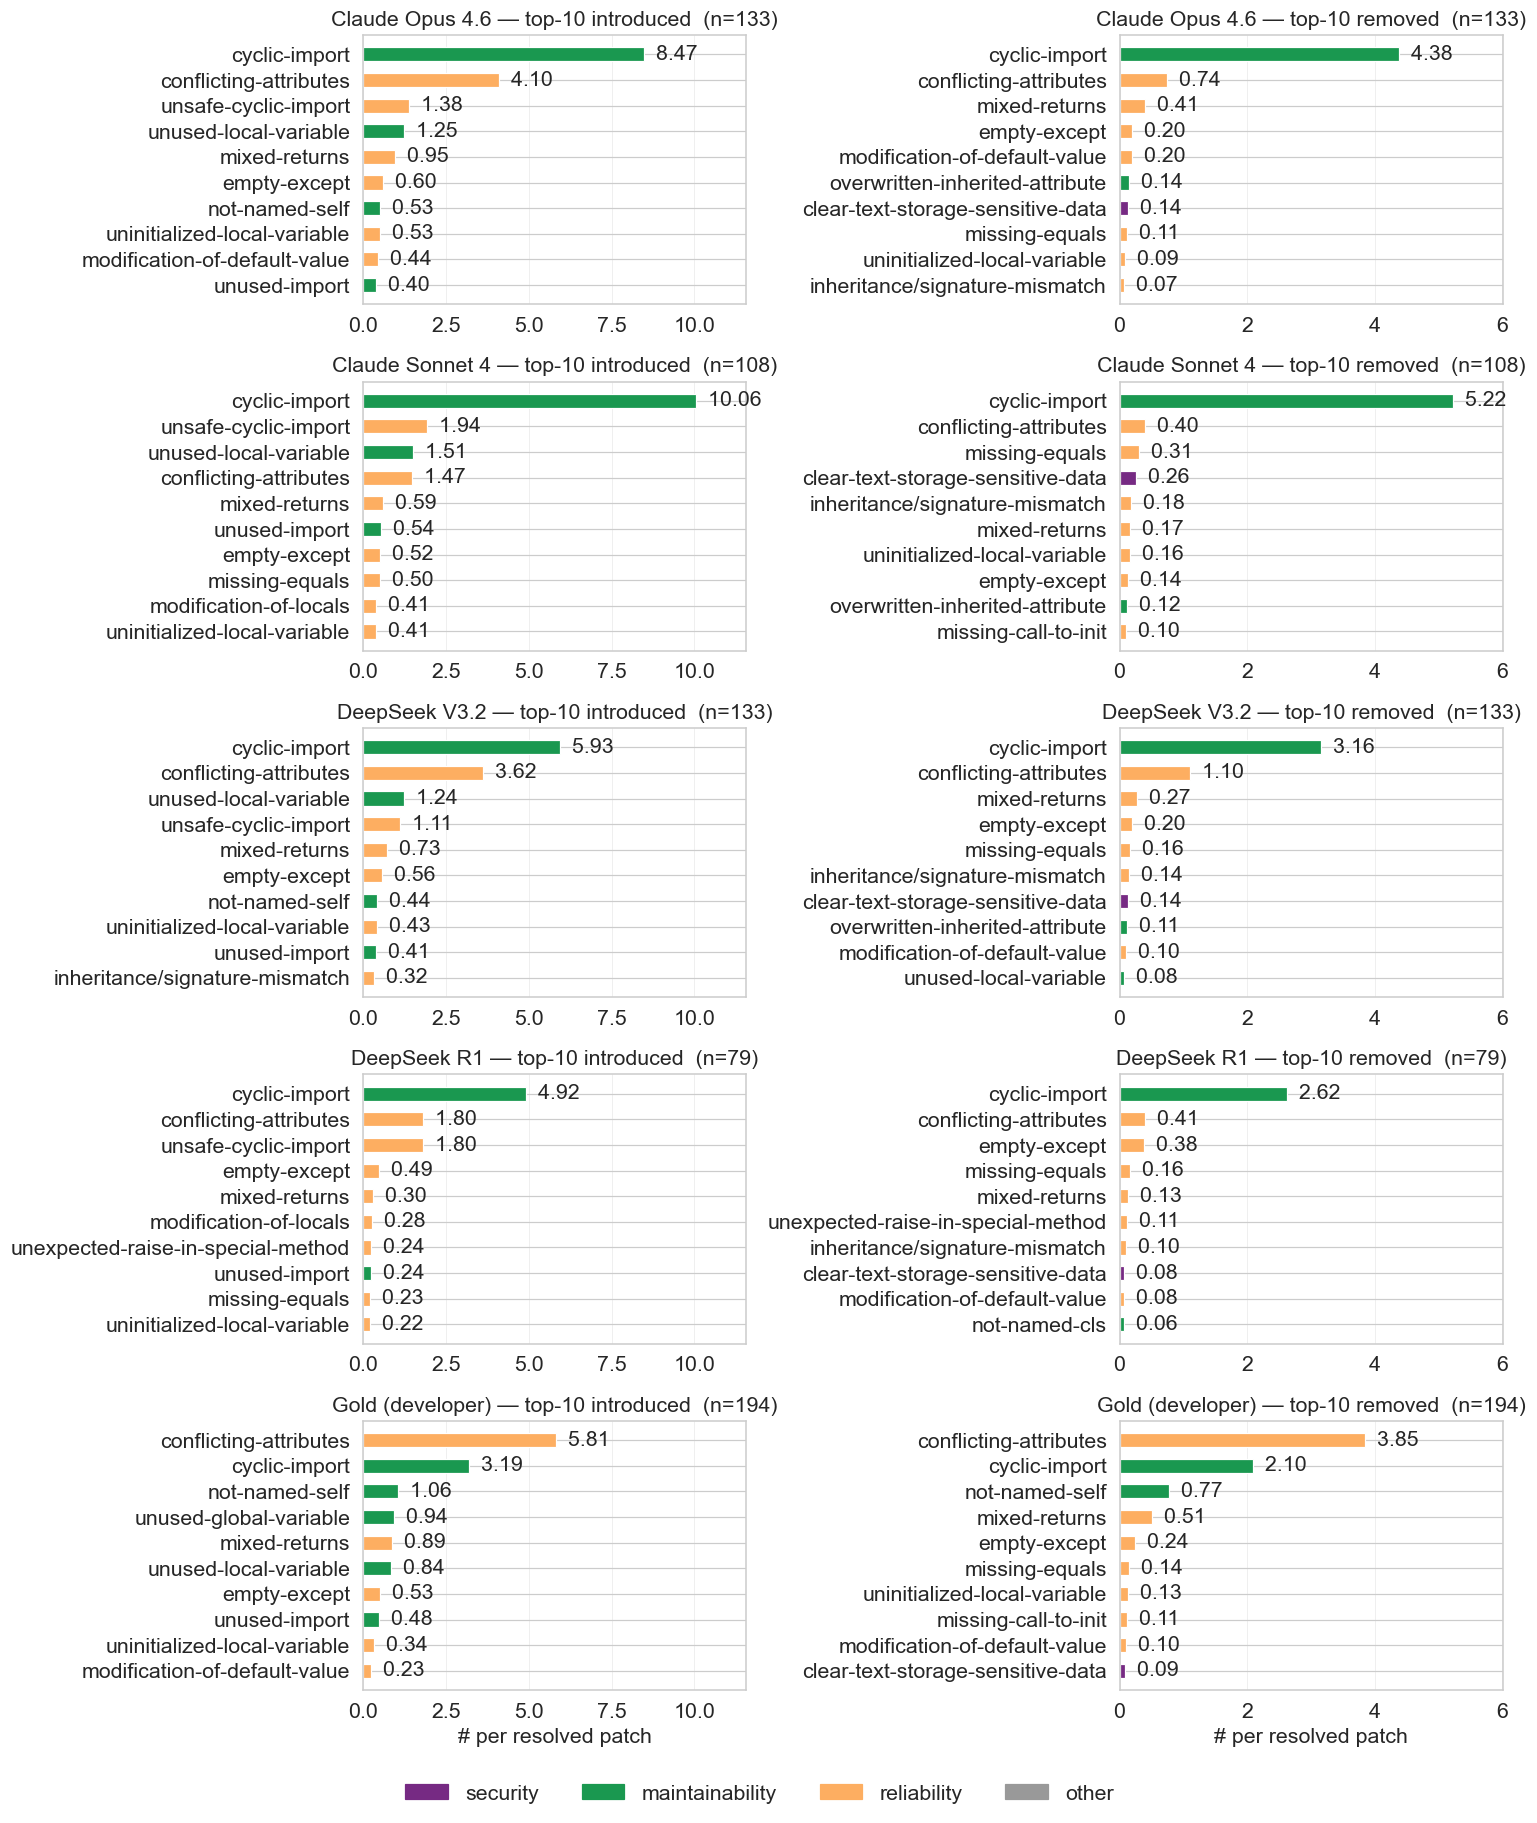


Top-10 introduced and removed rules per model (per resolved patch):

== Claude Opus 4.6  (n=133) ==
                     add_rule         add_cat  add/patch                          rem_rule         rem_cat  rem/patch
                cyclic-import maintainability       8.47                     cyclic-import maintainability       4.38
       conflicting-attributes     reliability       4.10            conflicting-attributes     reliability       0.74
         unsafe-cyclic-import     reliability       1.38                     mixed-returns     reliability       0.41
        unused-local-variable maintainability       1.25                      empty-except     reliability       0.20
                mixed-returns     reliability       0.95     modification-of-default-value     reliability       0.20
                 empty-except     reliability       0.60   overwritten-inherited-attribute maintainability       0.14
               not-named-self maintainability       0.53 clear-text-stora

In [4]:
# Per-model top-10 introduced / removed CodeQL rules, expressed as
# *mean count per resolved patch* (#events / n_resolved). Ranking inside a
# panel is unchanged vs raw counts (same denominator), but bar lengths are
# now comparable across models with different resolved-set sizes.
ORDER_ALL = MODEL_ORDER_WITH_GOLD
CAT_COLORS = {'security':'#762a83', 'maintainability':'#1a9850',
              'reliability':'#fdae61', 'other':'#999999'}

n_res_all = summary.set_index('model')['n_codeql_resolved_intersect'].reindex(ORDER_ALL).astype(float)

rules = ql_rule.merge(catalog[['ruleId','category']], on='ruleId', how='left',
                     suffixes=('','_cat'))
rules['category'] = rules['category'].fillna(rules['category_cat']).fillna('other')
rules['added_rate']   = rules.apply(lambda r: r['added_count']  /n_res_all[r['model']], axis=1)
rules['removed_rate'] = rules.apply(lambda r: r['removed_count']/n_res_all[r['model']], axis=1)

def top_rules(model, col, k=10):
    sub = (rules[rules['model']==model]
           .nlargest(k, col)[['ruleId','category',col]]
           .iloc[::-1])
    return sub

# global x-axis cap per column to keep bar scales visually comparable
max_add = max(top_rules(m, 'added_rate')['added_rate'].max()    for m in ORDER_ALL)
max_rem = max(top_rules(m, 'removed_rate')['removed_rate'].max() for m in ORDER_ALL)

fig, axes = plt.subplots(len(ORDER_ALL), 2, figsize=(14, 3.0*len(ORDER_ALL)+1.5))
for r, model in enumerate(ORDER_ALL):
    for col, title_word, ax, xmax in [
        ('added_rate',   'introduced', axes[r, 0], max_add),
        ('removed_rate', 'removed',    axes[r, 1], max_rem),
    ]:
        sub = top_rules(model, col)
        colors = [CAT_COLORS.get(cat, '#999999') for cat in sub['category']]
        bars = ax.barh(sub['ruleId'].str.removeprefix('py/'), sub[col], color=colors, height=0.55)
        for b, v in zip(bars, sub[col]):
            ax.text(v, b.get_y()+b.get_height()/2, f'  {v:.2f}',
                    va='center', fontsize=14)
        ax.set_xlim(0, xmax*1.15)
        ax.tick_params(axis='y', labelsize=14)
        ax.tick_params(axis='x', labelsize=14)
        ax.set_title(f'{model} — top-10 {title_word}  (n={int(n_res_all[model])})',
                     fontsize=14)
        ax.grid(axis='x', linewidth=0.4, alpha=0.5)
        if r == len(ORDER_ALL)-1:
            ax.set_xlabel('# per resolved patch', fontsize=14)

handles = [plt.Rectangle((0,0),1,1, color=CAT_COLORS[c])
           for c in ['security','maintainability','reliability','other']]
fig.legend(handles, ['security','maintainability','reliability','other'],
           loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.01),
           frameon=False, fontsize=14)
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.savefig(FIG / 'fig_per_model_top_rules.png')
plt.show()

# printed reference table (per-patch rates)
print('\nTop-10 introduced and removed rules per model (per resolved patch):')
for m in ORDER_ALL:
    add = top_rules(m, 'added_rate').iloc[::-1].reset_index(drop=True)
    rem = top_rules(m, 'removed_rate').iloc[::-1].reset_index(drop=True)
    print(f'\n== {m}  (n={int(n_res_all[m])}) ==')
    add = add.assign(ruleId=lambda d: d['ruleId'].str.removeprefix('py/'))
    rem = rem.assign(ruleId=lambda d: d['ruleId'].str.removeprefix('py/'))
    tbl = pd.concat([
        add.rename(columns={'ruleId':'add_rule','category':'add_cat','added_rate':'add/patch'}),
        rem.rename(columns={'ruleId':'rem_rule','category':'rem_cat','removed_rate':'rem/patch'}),
    ], axis=1)
    print(tbl.round(2).to_string(index=False))


## §IV.E  Per-model CodeScene category signatures


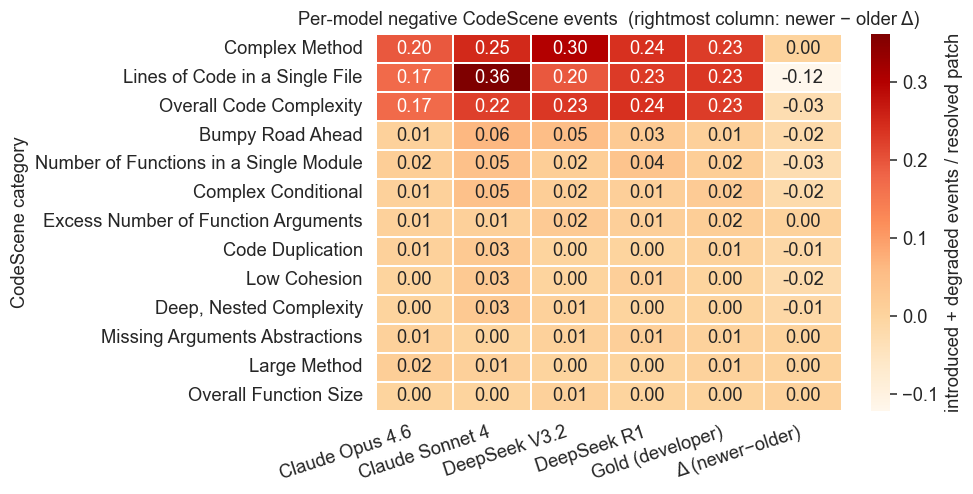

model,Claude Opus 4.6,Claude Sonnet 4,DeepSeek V3.2,DeepSeek R1,Gold (developer),Δ (newer−older)
category,,,,,,
Complex Method,0.195,0.250,0.301,0.241,0.227,0.002
Lines of Code in a Single File,0.173,0.361,0.195,0.228,0.232,-0.121
Overall Code Complexity,0.173,0.222,0.233,0.241,0.227,-0.027
Bumpy Road Ahead,0.008,0.065,0.053,0.025,0.010,-0.018
Number of Functions in a Single Module,0.015,0.046,0.015,0.038,0.015,-0.028
Complex Conditional,0.008,0.046,0.015,0.013,0.021,-0.021
Excess Number of Function Arguments,0.008,0.009,0.023,0.013,0.015,0.004
Code Duplication,0.008,0.028,0.000,0.000,0.005,-0.012
Low Cohesion,0.000,0.028,0.000,0.013,0.000,-0.021


In [5]:
# Per-model rate of negative CodeScene events per resolved patch, by category.
# Negative events = finding-level "introduced" + detail-level "degraded".
ORDER_ALL = MODEL_ORDER_WITH_GOLD
neg = cs_find[(cs_find['level']=='finding') & (cs_find['change_type']=='introduced')]\
        .groupby(['model','category'])['count'].sum().unstack(fill_value=0)
deg = cs_find[(cs_find['level']=='detail')  & (cs_find['change_type']=='degraded' )]\
        .groupby(['model','category'])['count'].sum().unstack(fill_value=0)
neg = neg.add(deg, fill_value=0)   # category x model totals of (introduced + degraded)
neg = neg.reindex(index=ORDER_ALL).fillna(0)

n_res_cs = cs_R.groupby('model').size().reindex(ORDER_ALL).astype(float)
rate = neg.div(n_res_cs, axis=0).T          # rows = category, cols = model
rate = rate.loc[rate.sum(axis=1).sort_values(ascending=False).index]   # most-touched on top

# also compute newer/older totals for the side annotation
NEWER = ['Claude Opus 4.6','DeepSeek V3.2']
OLDER = ['Claude Sonnet 4','DeepSeek R1']
n_new = n_res_cs[NEWER].sum(); n_old = n_res_cs[OLDER].sum()
rate['newer_rate'] = neg.loc[NEWER].sum(axis=0).reindex(rate.index).fillna(0) / n_new
rate['older_rate'] = neg.loc[OLDER].sum(axis=0).reindex(rate.index).fillna(0) / n_old
rate['Δ (newer−older)'] = rate['newer_rate'] - rate['older_rate']

display_cols = ORDER_ALL + ['Δ (newer−older)']
plt.figure(figsize=(9, max(4.5, 0.36*len(rate))))
sns.heatmap(rate[display_cols], annot=True, fmt='.2f', cmap='OrRd',
            annot_kws={'fontsize':12},
            cbar_kws={'label':'introduced + degraded events / resolved patch'},
            
            linewidths=0.3, linecolor='white')
plt.xticks(rotation=18, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('')
plt.ylabel('CodeScene category')
plt.title('Per-model negative CodeScene events  (rightmost column: newer − older Δ)')
plt.tight_layout()
plt.savefig(FIG / 'fig_per_model_cs_categories.png')
plt.show()
rate[display_cols].round(3)


## §IV.F  Dynamic performance — runtime, CPU, peak memory


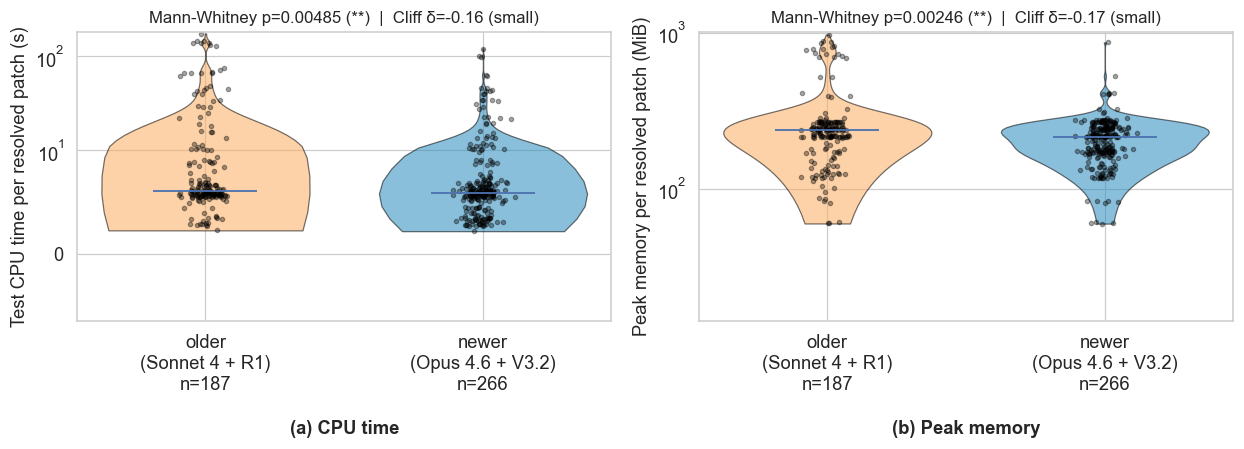


Per-model dynamic perf on resolved set:
model                     n   rt mean   rt med  cpu mean   cpu med   mem mean   mem med
Claude Opus 4.6         133     20.98     6.54     10.18      5.93      215.4     218.0
Claude Sonnet 4         108     27.62     6.90     17.87      5.97      284.9     242.6
DeepSeek V3.2           133     18.78     6.43      9.05      5.92      206.2     214.6
DeepSeek R1              79     15.80     6.66     16.47      6.30      241.3     215.8
Gold (developer)        194     21.01     6.69     15.06      6.01      240.8     215.9


In [6]:
# Dynamic perf on each model's own resolved set; newer-vs-older pooled comparison
# mirrors §IV.C for two dynamic indicators (CPU time + peak memory).
# (Wall-clock runtime is omitted from the figure because CPU time is the
# more meaningful aggregate; per-model wall-clock is still in the summary table.)
from scipy.stats import mannwhitneyu

dyn = pd.read_csv(CSV / 'dynamic_perf.csv')
ORDER_ALL = MODEL_ORDER_WITH_GOLD

RESOLVED_FILES = {
    'Claude Opus 4.6': ROOT/'data-0515/claude_out_default/evaluation-opus-4.6.opus0324.json',
    'Claude Sonnet 4': ROOT/'data-0515/sonnet4_out_default/evaluation-250526_sonnet.json',
    'DeepSeek V3.2':   ROOT/'data-0515/ds_out_default/evaluation-ds0324.json',
    'DeepSeek R1':     ROOT/'data-0515/r1_out_default/evaluation-ds-2025.json',
}
import json as _json
resolved = {m: set(_json.loads(p.read_text())['resolved_ids']) for m, p in RESOLVED_FILES.items()}
resolved['Gold (developer)'] = set().union(*resolved.values())

mask = dyn.apply(lambda r: r['instance_id'] in resolved.get(r['model'], set()), axis=1)
dyn_R = dyn[mask].copy()

GEN_MAP = {'Claude Opus 4.6':'newer', 'DeepSeek V3.2':'newer',
           'Claude Sonnet 4':'older', 'DeepSeek R1':'older'}
dyn_R['gen'] = dyn_R['model'].map(GEN_MAP)
dyn_RG = dyn_R[dyn_R['gen'].notna()].copy()

def cliffs_delta(x, y):
    import numpy as np
    x = np.asarray(x); y = np.asarray(y)
    return ((x[:,None] > y).sum() - (x[:,None] < y).sum()) / (len(x)*len(y))

def label(p, d):
    star = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'n.s.'))
    mag  = 'large'   if abs(d)>=0.474 else \
           'medium'  if abs(d)>=0.330 else \
           'small'   if abs(d)>=0.147 else 'negligible'
    return f'Mann-Whitney p={p:.3g} ({star})  |  Cliff δ={d:+.2f} ({mag})'

GEN_COLOR = {'older':'#fdae61','newer':'#2b8cbe'}
metrics = [
    ('cpu_mean',    'Test CPU time per resolved patch (s)', '(a) CPU time'),
    ('memory_mean', 'Peak memory per resolved patch (MiB)', '(b) Peak memory'),
]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
for ax, (col, ylab, title) in zip(axes, metrics):
    older = dyn_RG.loc[dyn_RG['gen']=='older', col].dropna().values
    newer = dyn_RG.loc[dyn_RG['gen']=='newer', col].dropna().values
    u, p = mannwhitneyu(newer, older, alternative='two-sided')
    d    = cliffs_delta(newer, older)

    parts = ax.violinplot([older, newer], positions=[0,1], widths=0.75,
                         showmedians=True, showextrema=False)
    for body, g in zip(parts['bodies'], ['older','newer']):
        body.set_facecolor(GEN_COLOR[g]); body.set_alpha(0.55); body.set_edgecolor('black')
    for i, arr in enumerate([older, newer]):
        rng = np.random.default_rng(i)
        ax.scatter(i + rng.normal(0, 0.04, len(arr)), arr, s=8, alpha=0.35, color='black')
    ax.set_xticks([0,1])
    ax.set_xticklabels([f'older\n(Sonnet 4 + R1)\nn={len(older)}',
                        f'newer\n(Opus 4.6 + V3.2)\nn={len(newer)}'])
    ax.set_yscale('symlog', linthresh=10)
    ax.set_ylabel(ylab)
    ax.text(0.5, 1.02, label(p, d), transform=ax.transAxes,
            ha='center', va='bottom', fontsize=11)
    ax.annotate(title, xy=(0.5, -0.34), xycoords='axes fraction',
                ha='center', va='top', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG / 'fig_dynamic_perf.png')
plt.show()

# Per-model summary table with both mean and median
print('\nPer-model dynamic perf on resolved set:')
print(f"{'model':<22} {'n':>4} "
      f"{'rt mean':>9} {'rt med':>8} "
      f"{'cpu mean':>9} {'cpu med':>9} "
      f"{'mem mean':>10} {'mem med':>9}")
for m in ORDER_ALL:
    sub = dyn_R[dyn_R['model']==m]
    if len(sub)==0: continue
    rt  = sub['runtime_mean'].dropna()
    cpu = sub['cpu_mean'].dropna()
    mem = sub['memory_mean'].dropna()
    print(f'{m:<22} {len(sub):>4} '
          f'{rt.mean():>9.2f} {rt.median():>8.2f} '
          f'{cpu.mean():>9.2f} {cpu.median():>9.2f} '
          f'{mem.mean():>10.1f} {mem.median():>9.1f}')
